[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/powerzoojax/PowerZooPy/blob/main/docs/en/examples/notebooks/nb01_quickstart.ipynb)

# NB01 — Quickstart

> **Prerequisites**: `pip install powerzoo stable-baselines3`  ·  **Time**: ~5 minutes

In this notebook you will:

1. **Browse** the benchmark task catalog
2. **Create** a single-agent battery arbitrage environment
3. **Run** a random episode and visualise reward + SOC
4. **Train** a PPO agent with Stable-Baselines3
5. **Evaluate** PPO vs Random and compare with a bar chart

**Battery arbitrage** — a single battery on a 33-bus distribution grid buys energy during off-peak hours (low price) and sells during peak hours (high price). The agent outputs one continuous charge/discharge action per step.

The **normalized score** maps mean episode return linearly between a random baseline (0) and an oracle baseline (1):

$$\text{normalized score} = \frac{\text{policy score} - \text{random score}}{\text{oracle score} - \text{random score}}$$

## 1. Setup

In [1]:
# Colab / fresh env: uncomment the next line
# !pip install powerzoo stable-baselines3 -q

import warnings; warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_formats = ['retina']

from powerzoo.tasks import make_task_env, list_public_tasks
from powerzoo.tasks.public import get_public_task_info
from powerzoo.benchmarks.policies import RandomPolicy
from powerzoo.benchmarks import evaluate
from powerzoo.benchmarks.viz import plot_episode, plot_dispatch, plot_eval_comparison

import powerzoo
print(f"PowerZoo {powerzoo.__version__}")

PowerZoo 0.2.0


## 2. Browse available tasks

In [2]:
import pandas as pd

print("Public benchmark tasks:", list_public_tasks())

# Show detailed info for battery_arbitrage as a neat table
info = get_public_task_info("battery_arbitrage")
pd.DataFrame(
    {k: [str(v)] for k, v in info.items() if k not in ("split_dates",)},
).T.rename(columns={0: "battery_arbitrage"})

Public benchmark tasks: ['battery_arbitrage', 'marl_opf', 'marl_der_arbitrage', 'marl_ev_v2g', 'dc_scheduling', 'marl_uc', 'opf_118', 'opf_118_7d']


,battery_arbitrage
name,battery_arbitrage
description,"Battery energy arbitrage - buy low, sell high"
difficulty,simple
agent_mode,single
has_splits,True
eval_protocol,"{'n_episodes': 100, 'seed_start': 42, 'split':..."
grid_type,distribution
grid_case,Case33bw
default_episode_horizon_steps,48
default_observation_mode,flattened


## 3. Create an environment

**`battery_arbitrage`** — a single battery on a 33-bus distribution grid. The agent controls one continuous charge/discharge action (`Box(-0.2, 0.2, (1,))`). The reward encourages discharging during peak hours and charging during off-peak hours, with a penalty for SOC deviation.

This is a **single-agent** Gymnasium environment — no multi-agent wrapper needed.

In [3]:
env = make_task_env("battery_arbitrage", split="train")

print(f"Obs shape : {env.observation_space.shape}")
print(f"Act shape : {env.action_space.shape}")
print(f"Act range : [{env.action_space.low[0]:.2f}, {env.action_space.high[0]:.2f}] MW")

Grid: DistGridEnv | Case: Case33bw
  Time series: 26113 steps, 2023-07-05 00:00:00+00:00 → 2024-12-31 23:30:00+00:00
  Columns: ['ActualDemand', 'Solar', 'Wind']

Scaling GB demand → Case33bw (33-bus, 1 units)...
  Case total gen capacity: 10.00 MW
  Original GB demand range: 12088.00 – 50786.00 MW
  Scaled load range: 2.02 - 8.50 MW
  Load ratio: 20.2% - 85.0% of capacity
  Pre-computed node loads: (26113, 33) (6.57 MB)
  Total days available: 545
Obs shape : (108,)
Act shape : (1,)
Act range : [-0.20, 0.20] MW


## 4. Run a random episode

Collect per-step rewards and battery state-of-charge (SOC), then visualise both trajectories.

Random policy: 48 steps, return = -8.67


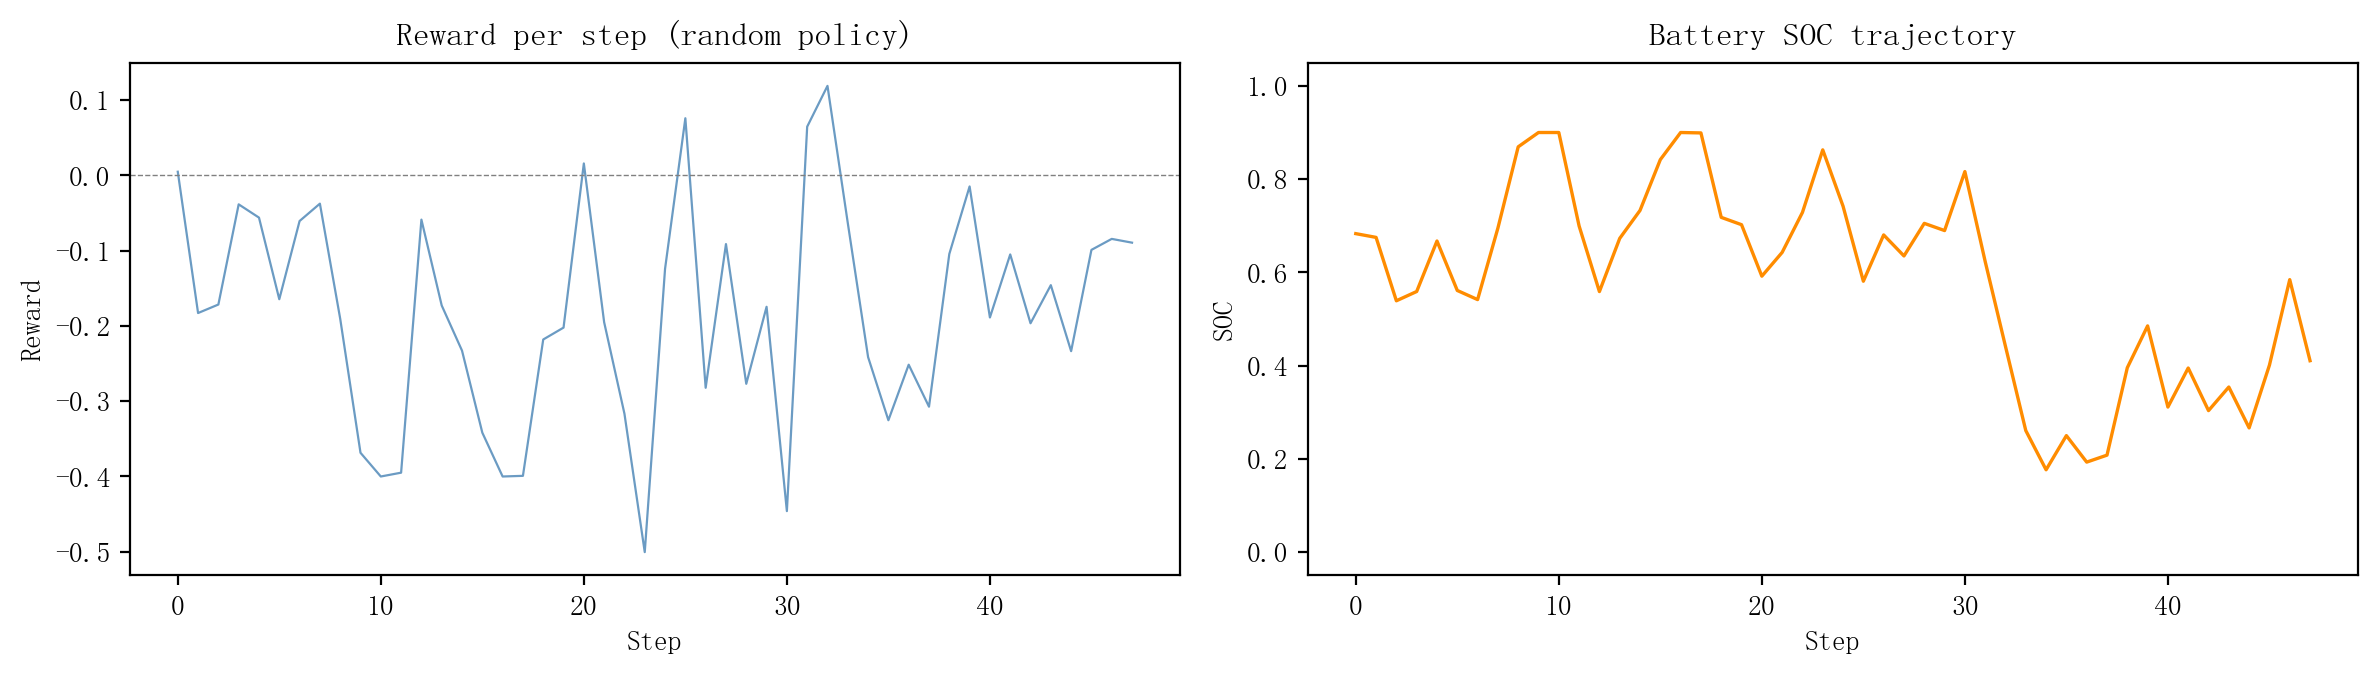

In [4]:
obs, info = env.reset(seed=42)

step_rewards, soc_list = [], []
terminated = truncated = False

while not (terminated or truncated):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    step_rewards.append(float(reward))
    soc_list.append(info['resources']['battery_0']['soc'])

print(f"Random policy: {len(step_rewards)} steps, return = {sum(step_rewards):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

# Left: reward per step
axes[0].plot(step_rewards, color="steelblue", alpha=0.8, linewidth=0.8)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Reward")
axes[0].set_title("Reward per step (random policy)")
axes[0].axhline(0, color="grey", linewidth=0.5, linestyle="--")

# Right: SOC trajectory
axes[1].plot(soc_list, color="darkorange", linewidth=1.2)
axes[1].set_xlabel("Step")
axes[1].set_ylabel("SOC")
axes[1].set_title("Battery SOC trajectory")
axes[1].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

## 5. Train with Stable-Baselines3

`battery_arbitrage` is a standard single-agent Gymnasium environment with `Box` observation and action spaces — no wrapper needed. We can pass it directly to PPO.

In [5]:
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback


# Callback to track episode returns during training
class RewardTracker(BaseCallback):
    def __init__(self):
        super().__init__()
        self.ep_rewards = []
        self._current = 0.0

    def _on_step(self):
        self._current += self.locals["rewards"][0]
        if self.locals["dones"][0]:
            self.ep_rewards.append(self._current)
            self._current = 0.0
        return True


tracker = RewardTracker()

model = PPO(
    "MlpPolicy", env,
    n_steps=96, batch_size=48, n_epochs=5, learning_rate=3e-4,
    verbose=0, seed=42,
)
model.learn(total_timesteps=10_000, callback=tracker)

print(f"Training done: {len(tracker.ep_rewards)} episodes")
print(f"  First 5 mean : {np.mean(tracker.ep_rewards[:5]):.2f}")
print(f"  Last  5 mean : {np.mean(tracker.ep_rewards[-5:]):.2f}")

Training done: 210 episodes
  First 5 mean : -12.22
  Last  5 mean : -6.24


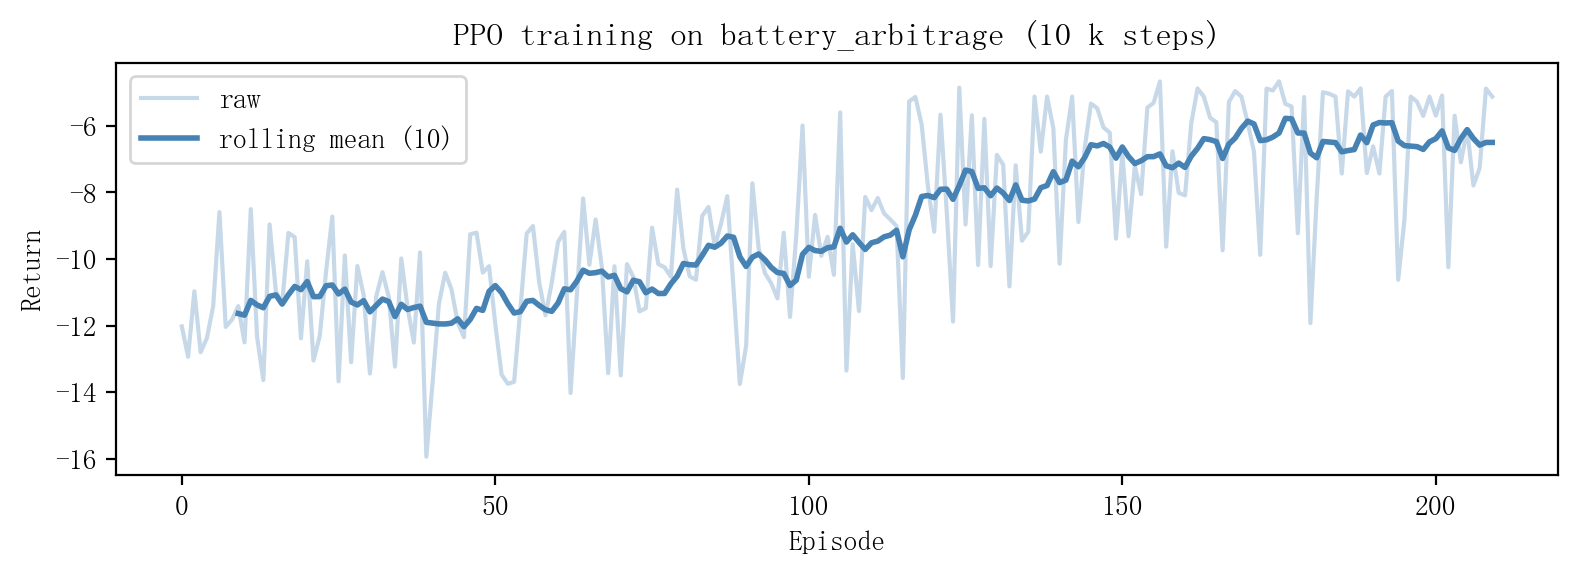

In [6]:
# Smooth the learning curve with a rolling window
window = min(10, max(1, len(tracker.ep_rewards) // 3))
smoothed = np.convolve(tracker.ep_rewards, np.ones(window) / window, mode="valid")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(tracker.ep_rewards, alpha=0.3, color="steelblue", label="raw")
ax.plot(range(window - 1, len(tracker.ep_rewards)), smoothed,
        color="steelblue", linewidth=2, label=f"rolling mean ({window})")
ax.set_xlabel("Episode")
ax.set_ylabel("Return")
ax.set_title("PPO training on battery_arbitrage (10 k steps)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Evaluate: PPO vs Random

Use `evaluate()` on the **test** split. It returns `mean_reward`, `std_reward`, and `normalized_score` (when baselines have been pre-computed).

Grid: DistGridEnv | Case: Case33bw
  Time series: 7997 steps, 2025-07-01 00:00:00+00:00 → 2025-12-15 00:00:00+00:00
  Columns: ['ActualDemand', 'Solar', 'Wind']

Scaling GB demand → Case33bw (33-bus, 1 units)...
  Case total gen capacity: 10.00 MW
  Original GB demand range: 13885.00 – 50434.00 MW
  Scaled load range: 2.34 - 8.50 MW
  Load ratio: 23.4% - 85.0% of capacity
  Pre-computed node loads: (7997, 33) (2.01 MB)
  Total days available: 167
=== PPO ===
  Episode   1/5: reward=   -5.130  cost=   0.000  steps=48
  Episode   2/5: reward=   -5.130  cost=   0.000  steps=48
  Episode   3/5: reward=   -5.130  cost=   0.000  steps=48
  Episode   4/5: reward=   -5.130  cost=   0.000  steps=48
  Episode   5/5: reward=   -5.130  cost=   0.000  steps=48

  Summary (5 episodes):
    mean ± std  = -5.130 ± 0.000
    min / max   = -5.130 / -5.130
    mean cost   = 0.000 ± 0.000
    throughput  = 723 steps/s

=== Random ===
  Episode   1/5: reward=  -11.051  cost=   0.000  steps=48
  Episode   2

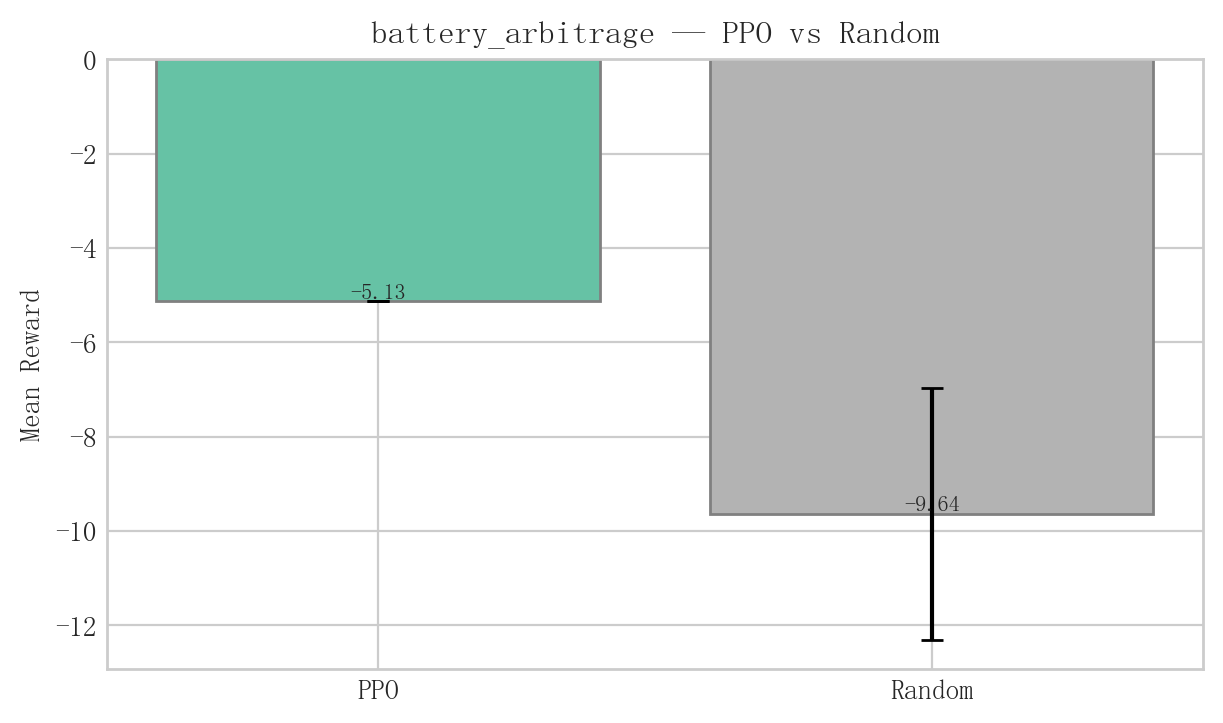

In [7]:
# Wrap SB3 model to match the evaluate() policy interface: act(obs, info) -> action
class SB3Policy:
    def __init__(self, model):
        self.model = model
    def act(self, obs, info=None):
        action, _ = self.model.predict(obs, deterministic=True)
        return action


test_env = make_task_env("battery_arbitrage", split="test")

print("=== PPO ===")
ppo_result = evaluate(
    SB3Policy(model), test_env, n_episodes=5, task_id="battery_arbitrage", verbose=True,
)

print("\n=== Random ===")
rand_result = evaluate(
    RandomPolicy(test_env.action_space, seed=0), test_env,
    n_episodes=5, task_id="battery_arbitrage", verbose=True,
)

# Visual comparison
fig = plot_eval_comparison(
    {"PPO": ppo_result, "Random": rand_result},
    metric="mean_reward", title="battery_arbitrage — PPO vs Random",
)
plt.show()

---

## Summary

| Step | Code | What it does |
|------|------|--------------|
| Create env | `make_task_env("battery_arbitrage", split="train")` | Single-agent Gymnasium env (Box spaces) |
| Train | `PPO("MlpPolicy", env).learn(10_000)` | Standard SB3 training loop — no wrapper needed |
| Evaluate | `evaluate(policy, env, task_id=...)` | Benchmark metrics + normalized score |

## Next steps

- Multi-agent training with RLlib or PettingZoo: [NB04 — OPF Task](./nb04_task_opf.ipynb)
- Evaluation details and normalized scores: [NB07 — Evaluation](./nb07_evaluation.ipynb)
- Full task catalog: [API: Tasks](../../api/tasks.md)